In [3]:
%load_ext autoreload
%autoreload 2

# Importing required modules and subpackages

In [4]:
from datetime import datetime, timedelta
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
mpl.rcParams["font.size"] = 12

The subpackage temporal will deal with the temporal analysis of the sea surface elevation data. AQUAlogger and RBR classes are also imported to load the sensor data.

In [5]:
from oceanicospy.observations import AQUAlogger,RBR
from oceanicospy.analysis import temporal

# Pressure data

The metadata of the deployment for each sensor is presented in a dictionary format, while the data files are passed as paths (strings).

In [ ]:
measurement_pressure_sensors_paths = ['../data/observations/AQ/','../data/observations/RBR/']

sampling_AQ = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=1,burst_length_s=2048,temperature=False,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=1))
sampling_RBR = dict(anchoring_depth=1,sensor_height=0.2,sampling_freq=2,burst_length_s=7200,
                            start_time=datetime(2025,5,9,10,0,0),end_time=datetime(2025,5,19,18,0,0)-timedelta(seconds=0.5))

Methods from the observations subpackage are used to load the raw pressure data from the sensors. The data is then cleaned and prepared for the temporal analysis. For further information about how to upload the sensor data using **oceanicospy**, please refer to the [data loading example](https://oceanicospy.readthedocs.io/en/latest/examples/data_loading.html).

In [7]:
sampling_data = [sampling_AQ,sampling_RBR]
metadata_list=['AQ','RBR']
dict_raw_measurements = dict()
dict_clean_measurements = dict()

for idx,measurement_path in enumerate(measurement_pressure_sensors_paths):
    if 'AQ' in measurement_path:
        object_device = AQUAlogger(measurement_path, sampling_data[idx])
    else:
        object_device = RBR(measurement_path,sampling_data[idx])

    raw_data = object_device.get_raw_records()
    clean_data = object_device.get_clean_records()
    dict_raw_measurements[metadata_list[idx]] = raw_data
    dict_clean_measurements[metadata_list[idx]] = clean_data

A quick look at each key (sensor) in the dictionary shows the measurements as pandas DataFrames.

In [8]:
dict_clean_measurements['AQ']

,pressure[bar],Raw2,depth[m],depth_aux[m],burstId,eta[m]
date,,,,,,
2025-05-09 10:00:00,1.245722,0,3.136509,2.307327,1,0.052596
2025-05-09 10:00:01,1.244709,0,3.124966,2.297273,1,0.041052
2025-05-09 10:00:02,1.237181,0,3.039040,2.222556,1,-0.044874
2025-05-09 10:00:03,1.243695,0,3.113418,2.287209,1,0.029503
2025-05-09 10:00:04,1.253249,0,3.222086,2.382034,1,0.138170
...,...,...,...,...,...,...
2025-05-19 16:34:03,1.239498,0,3.065513,2.245553,124,-0.003209
2025-05-19 16:34:04,1.242248,0,3.096910,2.272847,124,0.028177
2025-05-19 16:34:05,1.237905,0,3.047316,2.229742,124,-0.021427


In [9]:
dict_clean_measurements['RBR']

,pressure[bar],depth[m],burstId,eta[m]
date,,,,
2025-05-09 10:00:00.000,1.241829,2.267149,1,0.117985
2025-05-09 10:00:00.500,1.239702,2.246051,1,0.096886
2025-05-09 10:00:01.000,1.235314,2.202530,1,0.053365
2025-05-09 10:00:01.500,1.233978,2.189276,1,0.040110
2025-05-09 10:00:02.000,1.234466,2.194119,1,0.044954
...,...,...,...,...
2025-05-19 17:59:57.500,1.228489,2.134836,248,-0.044336
2025-05-19 17:59:58.000,1.228343,2.133389,248,-0.045786
2025-05-19 17:59:58.500,1.226372,2.113838,248,-0.065340


# Using the `WaveTemporalAnalyzer` class

First, we need to instanciate the `WaveTemporalAnalyzer` class, which will allow us to make the temporal analysis for the sensor data (whether be pressure, sea surface elevation, etc.). We need to provide the measured signal and the sampling data as arguments.

`WaveTemporalAnalyzer` will look for measurement signal with a column named "eta[m]", which is the standard name for the sea surface elevation in **oceanicospy**. If the column name is different, it can be specified as an argument when instanciating the class.

In [10]:
help(temporal.WaveTemporalAnalyzer)

Help on class WaveTemporalAnalyzer in module oceanicospy.analysis.temporal:

class WaveTemporalAnalyzer(builtins.object)
 |  WaveTemporalAnalyzer(measured_signal, sampling_data, surface_level_column='eta[m]')
 |  
 |  Methods defined here:
 |  
 |  __init__(self, measured_signal, sampling_data, surface_level_column='eta[m]')
 |      Initializes the analysis object with measurement signal and sampling data.
 |      
 |      Parameters
 |      ----------
 |      measured_signal : array-like
 |          The input signal data to be analyzed.
 |      sampling_data : dict
 |          Dictionary containing sampling parameters with the following keys:
 |              - 'sampling_freq' (float): Sampling frequency of the signal.
 |              - 'anchoring_depth' (float): Depth at which the sensor is anchored.
 |              - 'sensor_height' (float): Height of the sensor above the bottom.
 |              - 'burst_length_s' (float): Duration of each burst in seconds.
 |      surface_level_colu

## Zero upcrossing method

In [12]:
wave_params_dfs = dict()
for idx,metadata in enumerate(metadata_list):
    TemporalAnalyzer = temporal.WaveTemporalAnalyzer(dict_clean_measurements[metadata],sampling_data[idx])
    print(type(TemporalAnalyzer))
    wave_params_dfs[metadata_list[idx]] = TemporalAnalyzer.compute_params_from_zero_upcrossing()

<class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>
<class 'oceanicospy.analysis.temporal.WaveTemporalAnalyzer'>


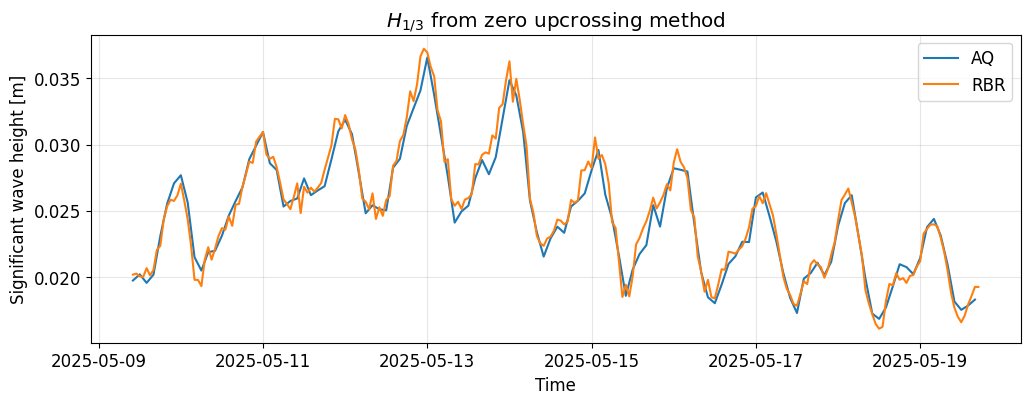

In [29]:
fig,ax = plt.subplots(1,1,figsize=(12,4))

ax.plot(wave_params_dfs['AQ']['H1/3'],label='AQ')
ax.plot(wave_params_dfs['RBR']['H1/3'],label='RBR')
ax.set(ylabel='Significant wave height [m]',xlabel='Time',title='$H_{1/3}$ from zero upcrossing method')
ax.grid(True,alpha=0.3)
ax.legend()
plt.show()

# Empirical mode decomposition (EMD) method

We can also use the EMD method to decompose the sea surface elevation signal into its intrinsic mode functions (IMFs). This can be useful to analyze the different frequency components of the signal.

In [13]:
help(temporal.WaveTemporalAnalyzer.decompose_into_IMFs_for_bursts)

Help on function decompose_into_IMFs_for_bursts in module oceanicospy.analysis.temporal:

decompose_into_IMFs_for_bursts(self, EMD_type, maximum_IMFs, number_ensembles=None, amplitude_noise_std=None, parallel=True, nb_processes=2)
    Decomposes the signal into Intrinsic Mode Functions (IMFs) for each burst using Empirical Mode Decomposition (EMD) 
    or its variants.
    
    Parameters
    ----------
    EMD_type : str
        The type of EMD to use. Options are 'EMD', 'EEMD', or 'CEEMDAN'.
    maximum_IMFs : int
        The maximum number of IMFs to compute for each burst.
    number_ensembles : int, optional
        The number of ensembles to use for EEMD or CEEMDAN (required if EMD_type is 'EEMD' or 'CEEMDAN').
    amplitude_noise_std : float, optional
        The standard deviation of the added noise for EEMD or CEEMDAN
    parallel : bool, optional
        Whether to use parallel processing for CEEMDAN (default is True).
    nb_processes : int, optional
        The number of pr

The shape of the resulting array of IMFs is (n_bursts, maximum_IMFs, burst_length_s), where `n_bursts` is the number of bursts in the measured signal, `maximum_IMFs` is the maximum number of IMFs specified as an argument, and `burst_length_s` is the length of each burst in seconds.

In [ ]:
TemporalAnalyzer_AQ = temporal.WaveTemporalAnalyzer(dict_clean_measurements['AQ'],sampling_data[0])
IMFs_burst_AQ = TemporalAnalyzer_AQ.decompose_into_IMFs_for_bursts(EMD_type='EEMD',maximum_IMFs=5,number_ensembles=100,amplitude_noise_std=0.3)

If you would want to visualize the 10th burst, we can plot the IMFs as follows:

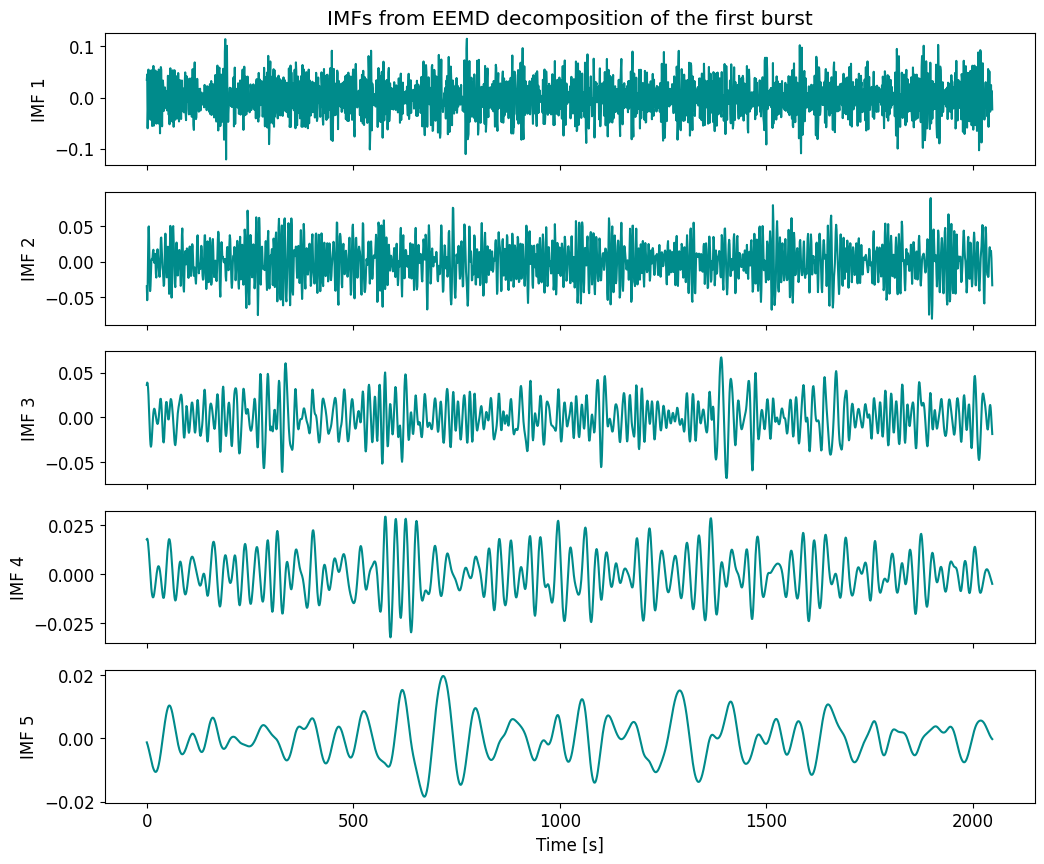

In [ ]:
fig,ax = plt.subplots(5,1,figsize=(12,10),sharex=True)
for i in range(5):
    ax[i].plot(IMFs_burst_AQ[10,i,:],color='darkcyan')
    ax[i].set(ylabel=f'IMF {i+1}')
ax[-1].set(xlabel='Time [s]')
ax[0].set_title('IMFs from EEMD decomposition of the 10th burst')
plt.show()

Those IMFs obtained from the function can be later used in combination with the spectral analysis to obtain the frequency content of each IMF, which can be useful to analyze the different frequency components of the signal.

In [26]:
TemporalAnalyzer_RBR= temporal.WaveTemporalAnalyzer(dict_clean_measurements['RBR'],sampling_data[1])
IMFs_burst_RBR = TemporalAnalyzer_RBR.decompose_into_IMFs_for_bursts(EMD_type='EMD',maximum_IMFs=7)

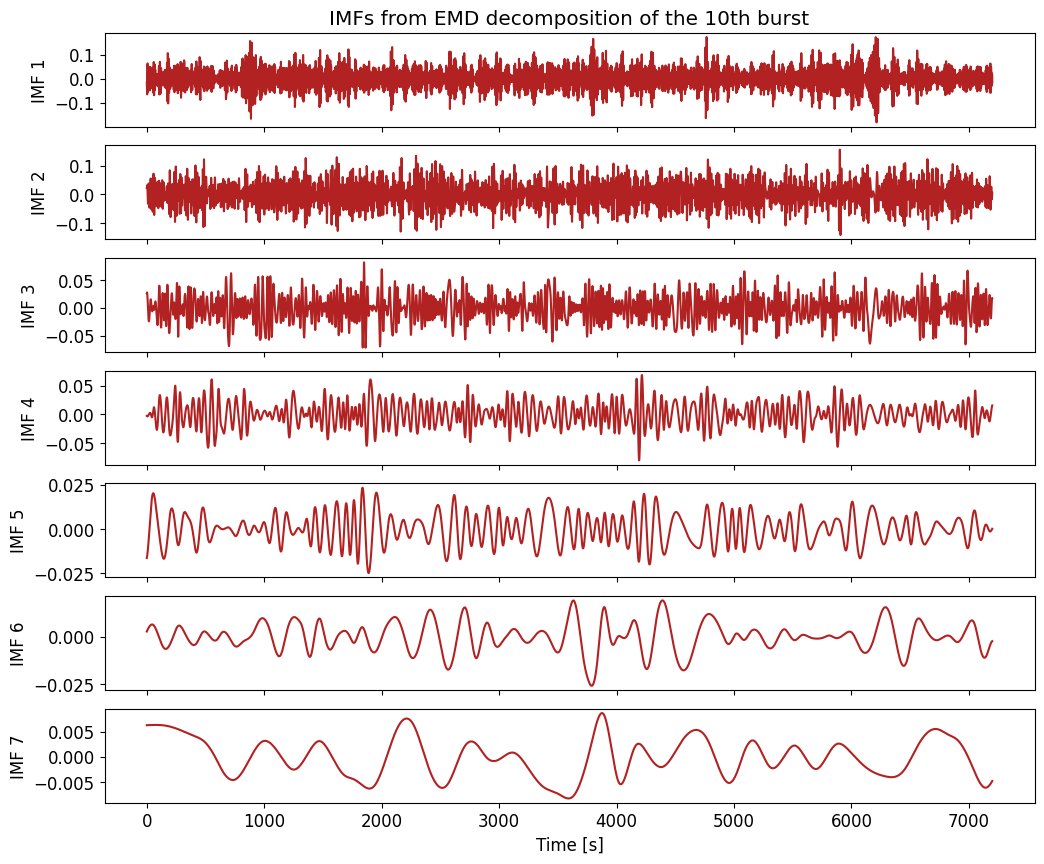

In [29]:
fig,ax = plt.subplots(7,1,figsize=(12,10),sharex=True)
for i in range(7):
    ax[i].plot(IMFs_burst_RBR[10,i,:],color='firebrick')
    ax[i].set(ylabel=f'IMF {i+1}')
ax[-1].set(xlabel='Time [s]')
ax[0].set_title('IMFs from EMD decomposition of the 10th burst')
plt.show()